Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os ,warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


Load The Dataset

In [2]:

df = pd.read_csv("E-Commerce-Customer.csv")
df.head()
df.shape

(3599, 18)

Inspect Dataset Structure

In [3]:
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3599 entries, 0 to 3598
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       3599 non-null   int64  
 1   Gender           3599 non-null   str    
 2   InvoiceDate      3599 non-null   str    
 3   InvoiceNumber    3599 non-null   int64  
 4   ProductID        3599 non-null   int64  
 5   Quantity         3599 non-null   int64  
 6   Price            3599 non-null   float64
 7   Total            3599 non-null   float64
 8   OrderStatus      3599 non-null   str    
 9   Country          3599 non-null   str    
 10  TrafficSource    3599 non-null   str    
 11  SessionDuration  3599 non-null   float64
 12  DeviceCategory   3599 non-null   str    
 13  Device           3599 non-null   str    
 14  OS               3599 non-null   str    
 15  DeliveryRating   3599 non-null   int64  
 16  ProductRating    3599 non-null   int64  
 17  Sales            3599 non

np.int64(0)

Prepare Invoice Date

In [4]:
df["InvoiceDate"] =pd.to_datetime(df["InvoiceDate"],format="mixed",errors="coerce")
print("Minimmum Invoice date:",df["InvoiceDate"].min())
print("Maximum Invoice date:",df["InvoiceDate"].max())
print("Missing dates:",df["InvoiceDate"].isna().sum())

Minimmum Invoice date: 2019-01-01 00:00:00
Maximum Invoice date: 2023-12-31 00:00:00
Missing dates: 0


Observation: The Invoice Date data is clean,w ith dates ranging from 2019 to 2023 and no missing values.

Create RFM table

In [5]:
reference_date = df["InvoiceDate"].max()+ pd.Timedelta(days=1)

In [6]:
rfm = df.groupby("CustomerID").agg(Recency=("InvoiceDate",lambda x:(reference_date - x.max()).days),Frequency=("InvoiceDate","count"),Monetary=("Price","sum")).reset_index()
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,1111,473,1,52.78
1,1114,213,1,87.34
2,1118,120,2,119.31
3,1119,218,1,72.93
4,1122,85,1,78.78


Observation: The RFM table was successfully created with Recency,Frequency, and Monetary values for each customer

Descriptive Statistics

In [7]:
print("Average Purchase Value:",df["Price"].mean())
print("Average Purchase Frequency:",rfm["Frequency"].mean())
print("Average customer Monetary Value:",rfm["Monetary"].mean())

Average Purchase Value: 48.714570714087245
Average Purchase Frequency: 1.215467747382641
Average customer Monetary Value: 59.21098953056399


Check RFM Distributions

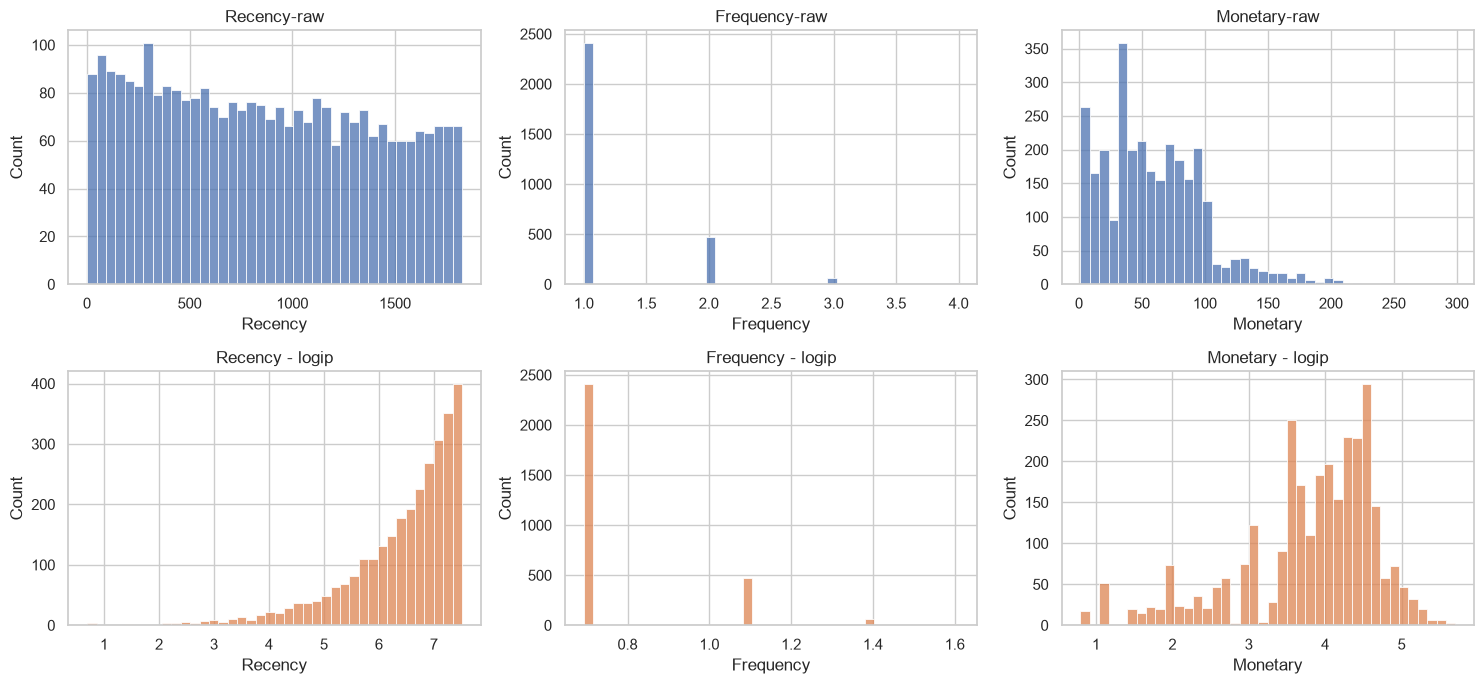

In [8]:
fig, axes = plt.subplots(2,3, figsize=(15,7))
for i, col in enumerate(["Recency","Frequency","Monetary"]):
    sns.histplot(rfm[col],bins= 40, ax=axes[0,i],color= "#4C72b0")
    axes[0, i].set_title(f"{col}-raw")
    sns.histplot(np.log1p(rfm[col]),bins= 40, ax=axes[1,i],color="#DD8452")
    axes[1,i].set_title(f"{col} - logip")
plt.tight_layout(); plt.show()    

Observation : The RFM graphs shows the Recency is widely high,Frequency and Monetary values are at lower levels. The below graphs show a more balanced distribution of RFM variables.

Standardisation

In [9]:
rfm_log = np.log1p(rfm[["Recency","Frequency","Monetary"]])
scaler = StandardScaler()
X = scaler.fit_transform(rfm_log)
print("Mean after scaling:",np.round(X.mean(axis=0),3))
print("Std after scaling:", np.round(X.std(axis=0),3))
pd.DataFrame(X,columns=["R","F","M"]).describe().round(2)

Mean after scaling: [-0.  0.  0.]
Std after scaling: [1. 1. 1.]


,R,F,M
count,2961.00,2961.00,2961.00
mean,-0.00,0.00,0.00
std,1.00,1.00,1.00
min,-5.59,-0.46,-3.25
25%,-0.45,-0.46,-0.34
50%,0.30,-0.46,0.22
75%,0.75,-0.46,0.73
max,1.07,4.56,2.09


K-Means and the Elbow Method

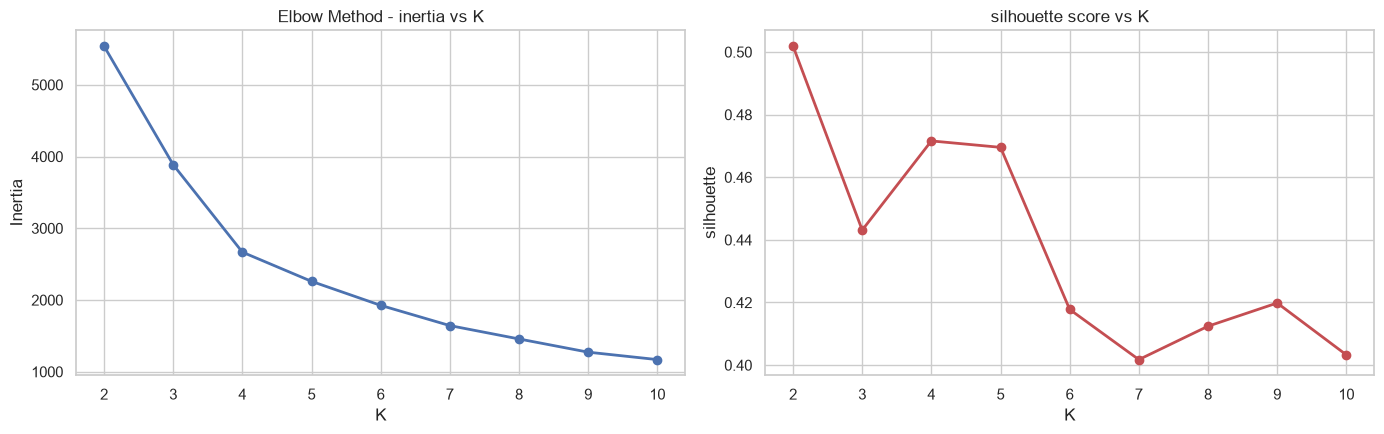

K=2 inertia=   5539.1 silhouette=0.502
K=3 inertia=   3885.8 silhouette=0.443
K=4 inertia=   2667.4 silhouette=0.472
K=5 inertia=   2260.1 silhouette=0.470
K=6 inertia=   1925.5 silhouette=0.418
K=7 inertia=   1643.4 silhouette=0.402
K=8 inertia=   1457.2 silhouette=0.412
K=9 inertia=   1273.0 silhouette=0.420
K=10 inertia=   1169.4 silhouette=0.403


In [10]:
RANDOM_STATE = 42
K_range = range(2,11)
inertia, sil = [],[]
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X,km.labels_))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(list(K_range), inertia, marker="o", lw=2)
axes[0].set_title("Elbow Method - inertia vs K"); axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia")  
axes[1].plot(list(K_range), sil, marker="o", lw=2, color= "#C44E52")
axes[1].set_title("silhouette score vs K"); axes[1].set_xlabel("K"); axes[1].set_ylabel("silhouette")
plt.tight_layout(); plt.show()
for k, i, s in zip(K_range, inertia, sil):
    print(f"K={k} inertia={i:9.1f} silhouette={s:.3f}")  

Observation: The Elbow Method shows the decrease in inertia  from K = 4. The silhouette score is also relatively high at K=4. It indicate that 4 clusters is a suitable choice for K-Means customer segmentation.

In [11]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(X)
print("silhouette score at K=4:", round(silhouette_score(X, rfm["Cluster"]), 3))
print(rfm["Cluster"].value_counts().sort_index())


silhouette score at K=4: 0.472
Cluster
0     530
1    1479
2     559
3     393
Name: count, dtype: int64


Visualizing the Clusters

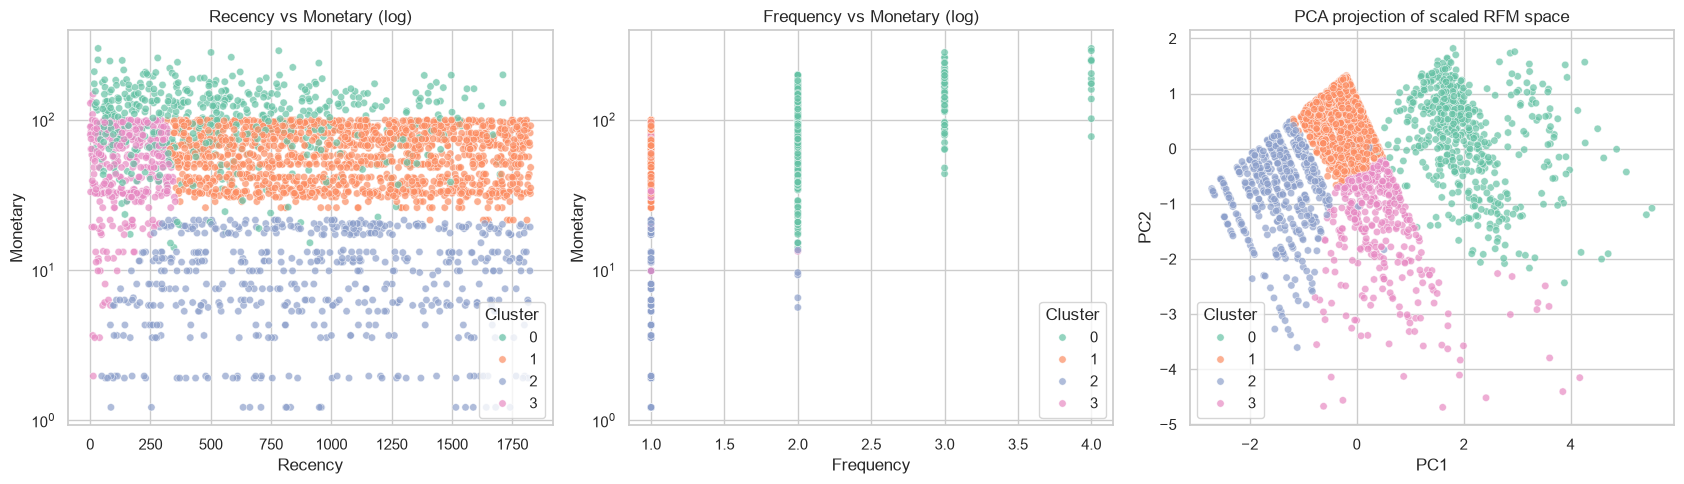

In [12]:
fig, axes=plt.subplots(1, 3, figsize=(17, 5))
pal = "Set2"
sns.scatterplot(data=rfm, x="Recency", y= "Monetary", hue="Cluster",palette=pal, alpha=.7, s=28,ax=axes[0])
axes[0].set_yscale("log"); axes[0].set_title("Recency vs Monetary (log)")
sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Cluster", palette=pal, alpha=.7, s=28, ax=axes[1])
axes[1].set_yscale("log"); axes[1].set_title("Frequency vs Monetary (log)")
pcs = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
sns.scatterplot(x=pcs[:,0], y=pcs[:, 1], hue=rfm["Cluster"],palette=pal, alpha=.7, s=28, ax=axes[2])
axes[2].set_title("PCA projection of scaled RFM space")
axes[2].set_xlabel("PC1"); axes[2].set_ylabel("PC2")
plt.tight_layout(); plt.show()

Observation: The cluster visualization shows that customers are divided into 4 clusters based on theeir RFM characteristics. The PCA plot also shows a reasonable seperation between clusters, it indicate different customer purchasing behaviours.

Cluster profiling

In [13]:
profile = rfm.groupby("Cluster").agg(
    Recency_mean = ("Recency","mean"),
    Frequency_mean = ("Frequency", "mean"),
    Monetary_mean = ("Monetary","mean"),
    Monetary_total = ("Monetary", "sum"),
    Customers = ("Recency", "size"),
).round(1)
profile["% of customers"] = (profile["Customers"]/ profile["Customers"].sum()* 100).round(1)
profile["% of revenue"] = (profile["Monetary_total"]/ profile["Monetary_total"].sum() * 100).round(1)

r_rank = profile["Recency_mean"].rank()
f_rank = profile["Frequency_mean"].rank(ascending=False)
m_rank = profile["Monetary_mean"].rank(ascending=False)
score = r_rank + f_rank + m_rank

order = score.sort_values().index
names = ["champions", "Loyal Customers", "Occasional Buyers", "At- Risk / Hibernating"]
name_map = {cl: nm for cl, nm in zip(order, names[:len(order)])}
profile["Segment"] =[name_map[c] for c in profile.index]
rfm["Segment"] = rfm["Cluster"].map(name_map)


profile[["Segment", "Recency_mean","Frequency_mean","Monetary_mean","Customers","% of customers","% of revenue"]]

,Segment,Recency_mean,Frequency_mean,Monetary_mean,Customers,% of customers,% of revenue
Cluster,,,,,,,
0,champions,579.3,2.2,108.3,530,17.9,32.7
1,Occasional Buyers,1098.3,1.0,61.0,1479,49.9,51.5
2,At- Risk / Hibernating,948.3,1.0,10.7,559,18.9,3.4
3,Loyal Customers,161.8,1.0,55.3,393,13.3,12.4


Observation: The cluster profiling shows clear difference among the four customer segments based on Recency,Frequency, and Monetary values.
In the above table chanpions are the highest value customers, Loyal customers show low spending. 

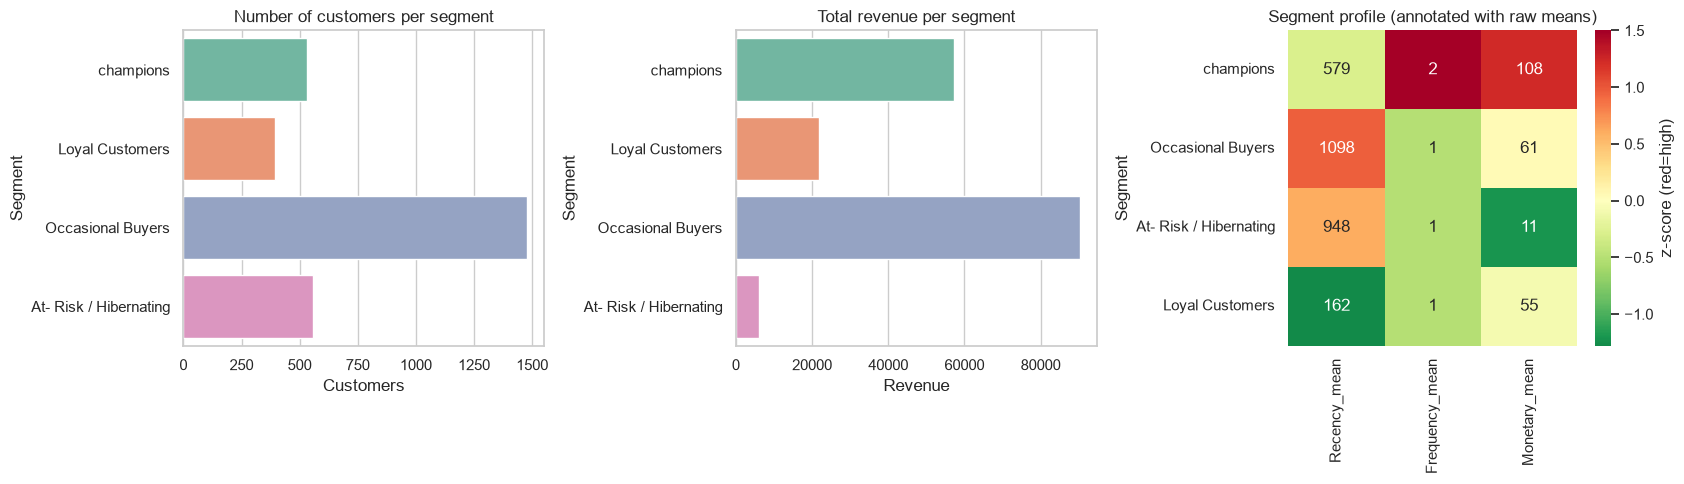

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17,5))
counts = rfm["Segment"].value_counts().reindex(names).dropna()
sns.barplot(x=counts.values, y=counts.index, ax=axes[0],palette="Set2")
axes[0].set_title("Number of customers per segment"); axes[0].set_xlabel("Customers")

rev = rfm.groupby("Segment")["Monetary"].sum().reindex(counts.index)
sns.barplot(x=rev.values, y=rev.index, ax=axes[1], palette="Set2")
axes[1].set_title("Total revenue per segment");axes[1].set_xlabel("Revenue")

heat = profile.set_index("Segment")[["Recency_mean","Frequency_mean","Monetary_mean"]]
heat_z = (heat - heat.mean())/ heat.std()
sns.heatmap(heat_z, annot=heat.round(0), fmt=".0f", cmap="RdYlGn_r", center=0, ax=axes[2], cbar_kws={"label": "z-score (red=high)"})
axes[2].set_title("Segment profile (annotated with raw means)")

plt.tight_layout(); plt.show()


Observation: The graphs show that occasional buyers have the highest number of customers and revenue also,while champions contribute high revenue with moderate customers.The segment comparison highlights customer count and revenue, helps to identify high and low value segments for targeted marketing strategies.